In [1]:
# Global Superstore Sales Analysis

## DevRise Internship Program – Task 1

### Objective
#The objective of this project is to perform data cleaning, exploratory data analysis (EDA), and visualization on the Global Superstore dataset. The analysis aims to uncover meaningful business insights related to sales performance, customer segments, product categories, regional trends, shipping efficiency, and profitability.

### Tools Used
"""
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook
"""

'\n- Python\n- Pandas\n- NumPy\n- Matplotlib\n- Seaborn\n- Jupyter Notebook\n'

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [4]:
# Load Dataset
df = pd.read_csv("Global Superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [5]:
df.columns = (
    df.columns
      .str.replace(".", " ", regex=False)
      .str.strip()
)

df.columns


Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', '记录数', 'Order Date', 'Order ID', 'Order Priority',
       'Product ID', 'Product Name', 'Profit', 'Quantity', 'Region', 'Row ID',
       'Sales', 'Segment', 'Ship Date', 'Ship Mode', 'Shipping Cost', 'State',
       'Sub Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [6]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,记录数,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Row ID,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [7]:
# Dataset Overview
df.shape

(51290, 27)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [9]:
df.describe()

,Discount,记录数,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [10]:
df.describe(include="object")

,Category,City,Country,Customer ID,Customer Name,Market,Order Date,Order ID,Order Priority,Product ID,Product Name,Region,Segment,Ship Date,Ship Mode,State,Sub Category,Market2
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,3,3636,147,4873,795,7,1430,25035,4,10292,3788,13,3,1464,4,1094,17,6
top,Office Supplies,New York City,United States,JG-158051,Muhammed Yedwab,APAC,2014-06-18 00:00:00.000,CA-2014-100111,Medium,OFF-AR-10003651,Staples,Central,Consumer,2014-11-22 00:00:00.000,Standard Class,California,Binders,APAC
freq,31273,915,9994,40,108,11002,135,14,29433,35,227,11117,26518,130,30775,2001,6152,11002


In [11]:
# Data Cleaning
df.isnull().sum()

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
记录数               0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [15]:
df["Delivery Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

df["Month"] = df["Order Date"].dt.month_name()

df["Year"] = df["Order Date"].dt.year

df["Profit Margin"] = (
    df["Profit"] /
    df["Sales"]
) * 100

In [16]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,记录数,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Row ID,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub Category,Year,Market2,weeknum,Delivery Days,Month,Profit Margin
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2,2,January,49.111579
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4,5,January,48.909474
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32,4,August,46.865714
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32,4,August,47.982703
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40,4,September,51.840000


In [17]:
# Exploratory Data Analysis
print(f"Total Orders: {len(df):,}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Average Discount: {df['Discount'].mean():.2%}")
print(f"Average Delivery Days: {df['Delivery Days'].mean():.2f}")

print("Total Sales :",df["Sales"].sum())

Total Orders: 51,290
Total Sales: $12,642,905.00
Total Profit: $1,467,457.29
Average Discount: 14.29%
Average Delivery Days: 3.97
Total Sales : 12642905


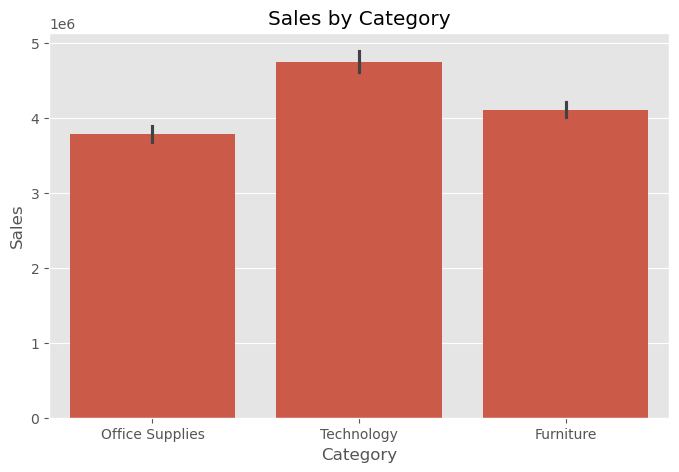

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator=sum
)
plt.savefig("Sales by Category.png", dpi=300, bbox_inches="tight")

plt.title("Sales by Category")
plt.show()

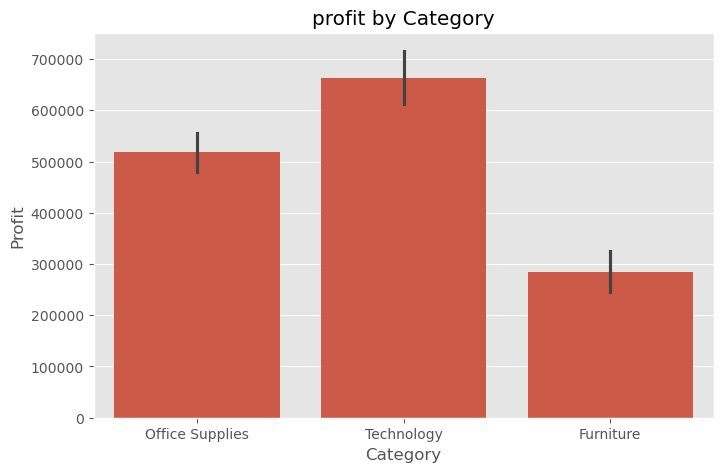

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator=sum
)
plt.savefig("Profit by Category.png", dpi=300, bbox_inches="tight")

plt.title("profit by Category")
plt.show()

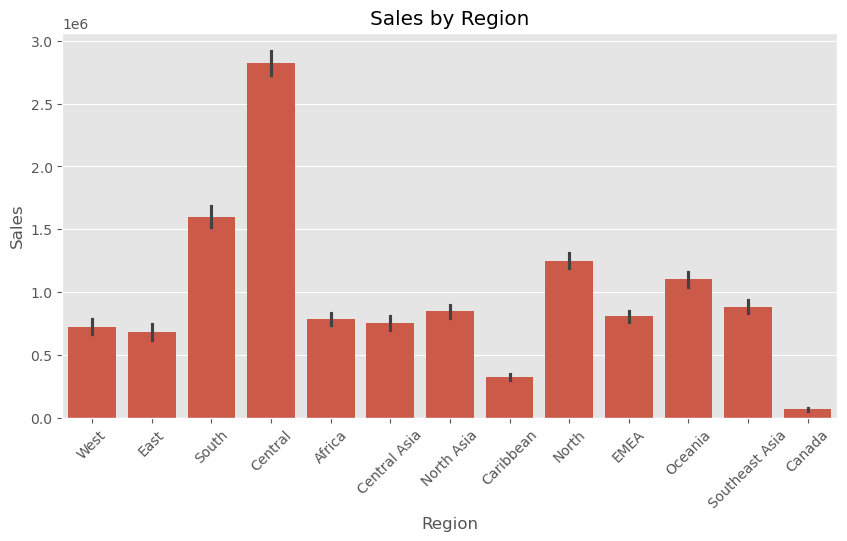

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator=sum
)
plt.savefig("Sales by Region.png", dpi=300, bbox_inches="tight")

plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()

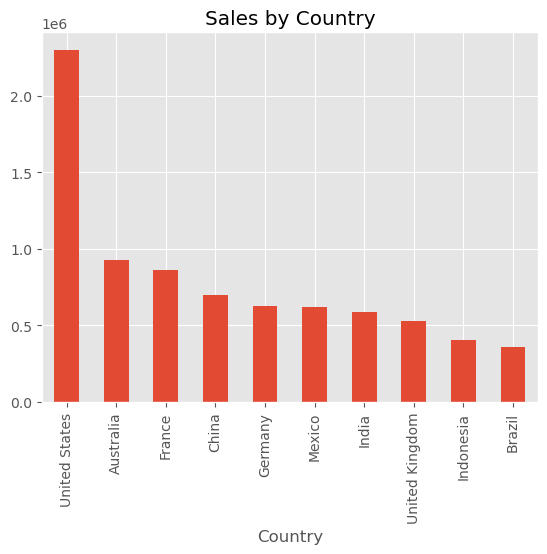

In [21]:
top_country = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.savefig("Sales by Country.png", dpi=300, bbox_inches="tight")

plt.title("Sales by Country")
top_country.plot(kind="bar")
plt.show()

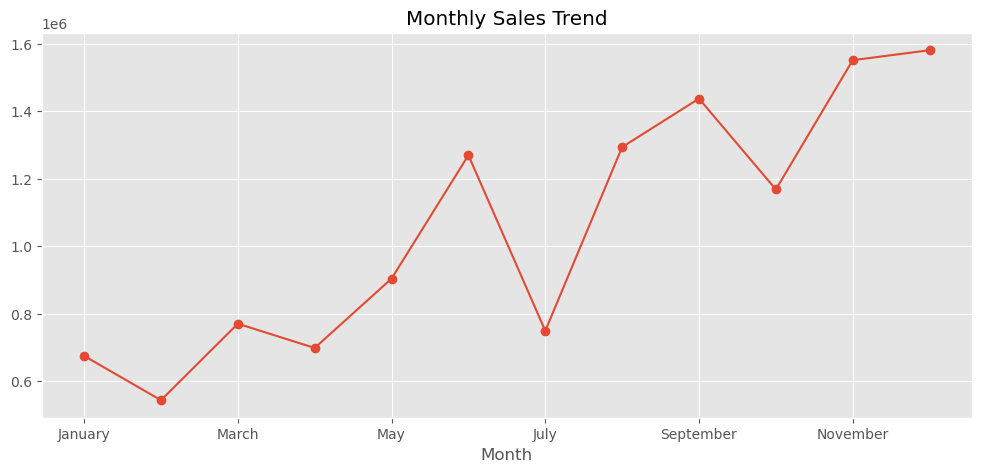

In [22]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = (
    df.groupby("Month")["Sales"]
      .sum()
      .reindex(month_order)
)

monthly.plot(figsize=(12,5),marker="o")
plt.savefig("Monthly Sales Trend.png", dpi=300, bbox_inches="tight")

plt.title("Monthly Sales Trend")
plt.show()

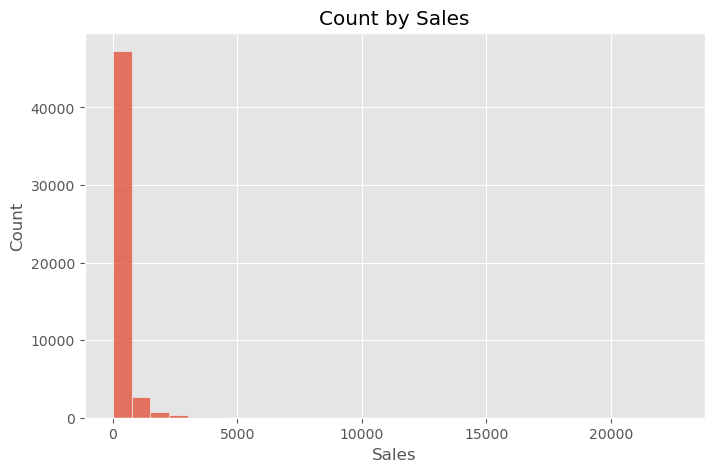

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"],bins=30)
plt.savefig("Count by Sales.png", dpi=300, bbox_inches="tight")

plt.title("Count by Sales")
plt.show()

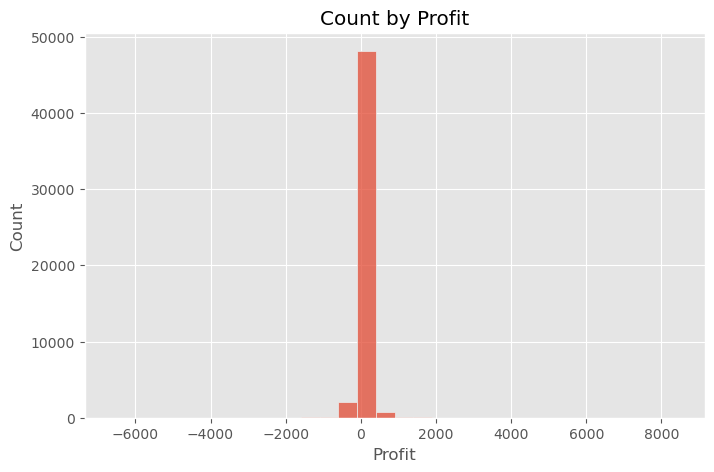

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"],bins=30)
plt.savefig("Count by Profit.png", dpi=300, bbox_inches="tight")

plt.title("Count by Profit")
plt.show()

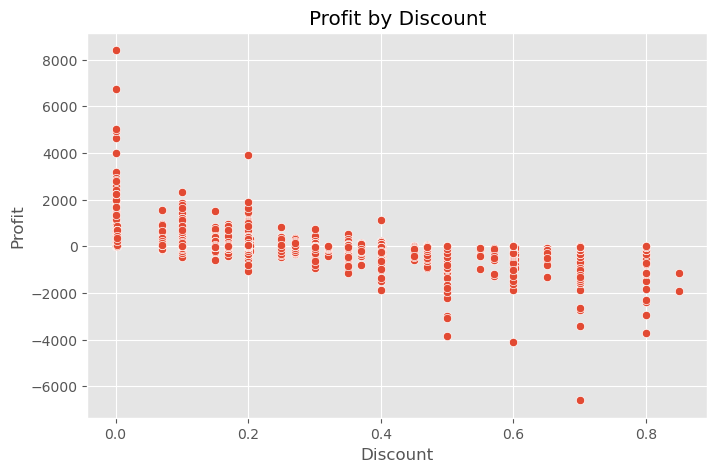

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)
plt.savefig("Profit by Discount.png", dpi=300, bbox_inches="tight")

plt.title("Profit by Discount")
plt.show()

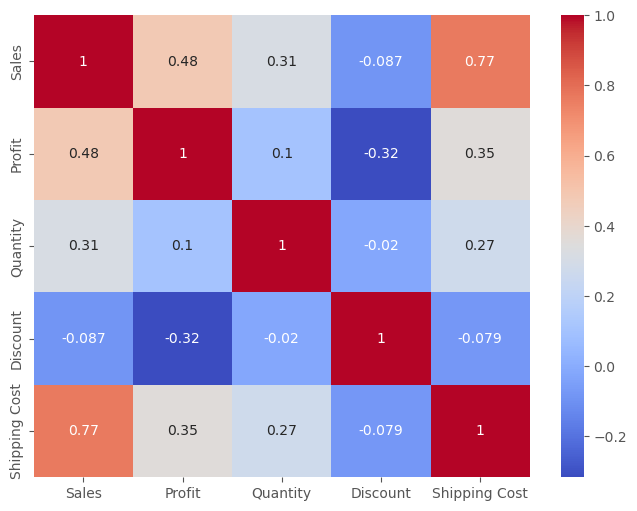

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            "Sales",
            "Profit",
            "Quantity",
            "Discount",
            "Shipping Cost"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.savefig("Heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

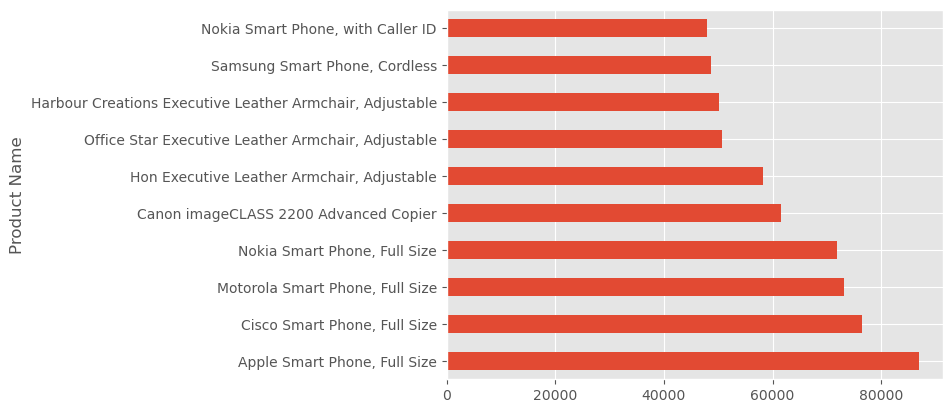

In [27]:
top = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.savefig("Top Products.png", dpi=300, bbox_inches="tight")

top.plot(kind="barh")
plt.show()

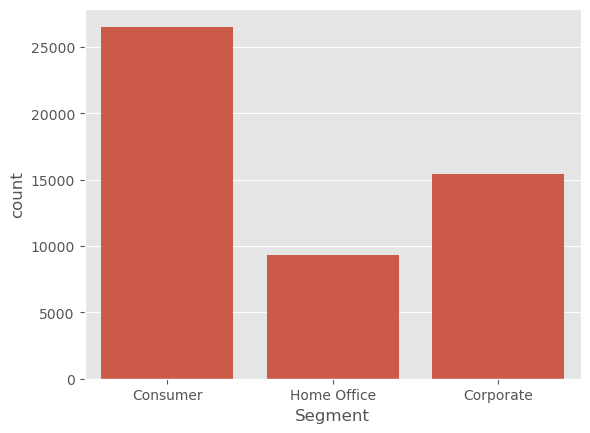

In [28]:
sns.countplot(
    data=df,
    x="Segment"
)

plt.show()

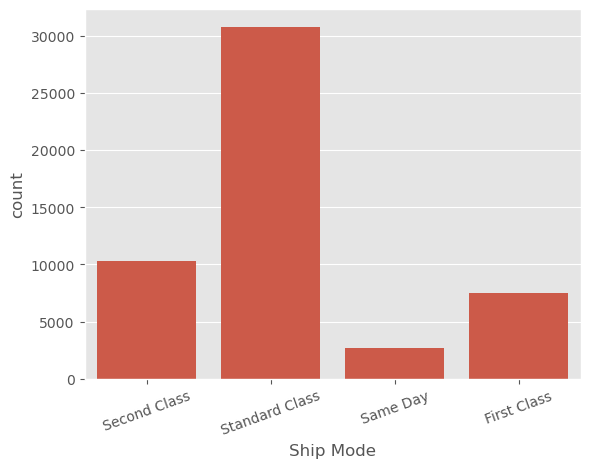

In [29]:
sns.countplot(
    data=df,
    x="Ship Mode"
)

plt.xticks(rotation=20)

plt.show()

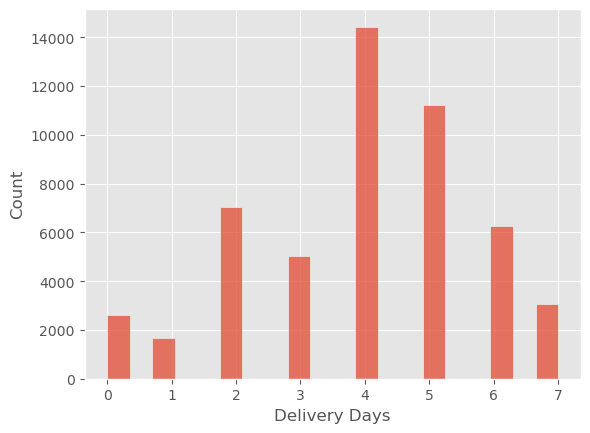

In [30]:
sns.histplot(
    df["Delivery Days"],
    bins=20
)

plt.show()

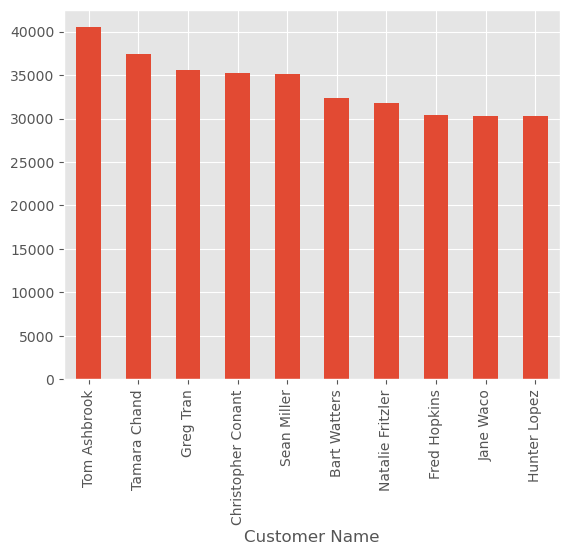

In [31]:
customer = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

customer.plot(kind="bar")

plt.show()

In [32]:
# Business Insights

### Key Findings
"""
- Technology products generated the highest sales.
- Consumer segment contributed the largest share of revenue.
- Standard Class shipping was used most frequently.
- Higher discounts generally resulted in lower profits.
- Certain regions achieved high sales but comparatively lower profitability.
- Delivery time varied across shipping modes.
- A small number of products accounted for a large share of sales.
"""

'\n- Technology products generated the highest sales.\n- Consumer segment contributed the largest share of revenue.\n- Standard Class shipping was used most frequently.\n- Higher discounts generally resulted in lower profits.\n- Certain regions achieved high sales but comparatively lower profitability.\n- Delivery time varied across shipping modes.\n- A small number of products accounted for a large share of sales.\n'

In [33]:
# Conclusion

#This project successfully demonstrated the complete data analysis pipeline, including data cleaning, exploratory data analysis, and visualization using Python. 
#The insights generated from the Global Superstore dataset highlight important business trends in sales, profitability, customer behavior, and shipping performance. 
#The findings can support better decision-making in inventory management, pricing, and logistics.

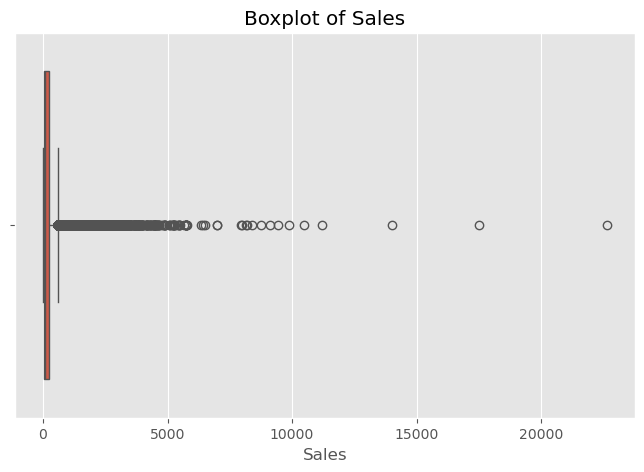

Observation:
The boxplot shows several high-value outliers in the Sales column. These represent unusually large transactions, which are common in retail datasets. Such outliers may influence the average sales and should be considered during further analysis.


In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Sales"])

plt.title("Boxplot of Sales")
plt.xlabel("Sales")

plt.show()
print("Observation:")
print("The boxplot shows several high-value outliers in the Sales column. These represent unusually large transactions, which are common in retail datasets. Such outliers may influence the average sales and should be considered during further analysis.")

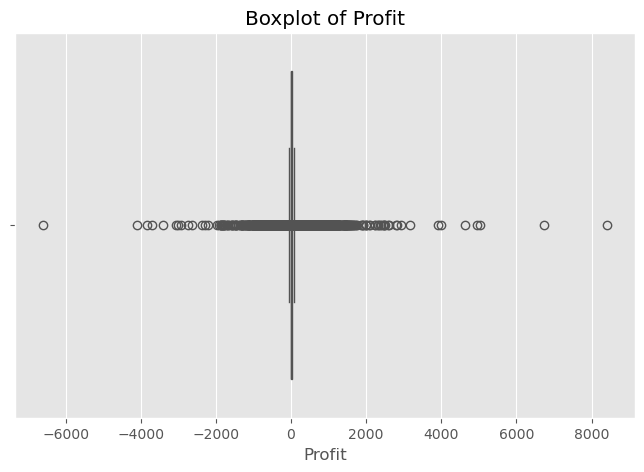

Observation:
The Profit distribution contains both positive and negative outliers. Negative values indicate loss-making orders, which may require further business investigation.


In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Profit"])

plt.title("Boxplot of Profit")
plt.xlabel("Profit")

plt.show()

print("Observation:")
print("The Profit distribution contains both positive and negative outliers. Negative values indicate loss-making orders, which may require further business investigation.")

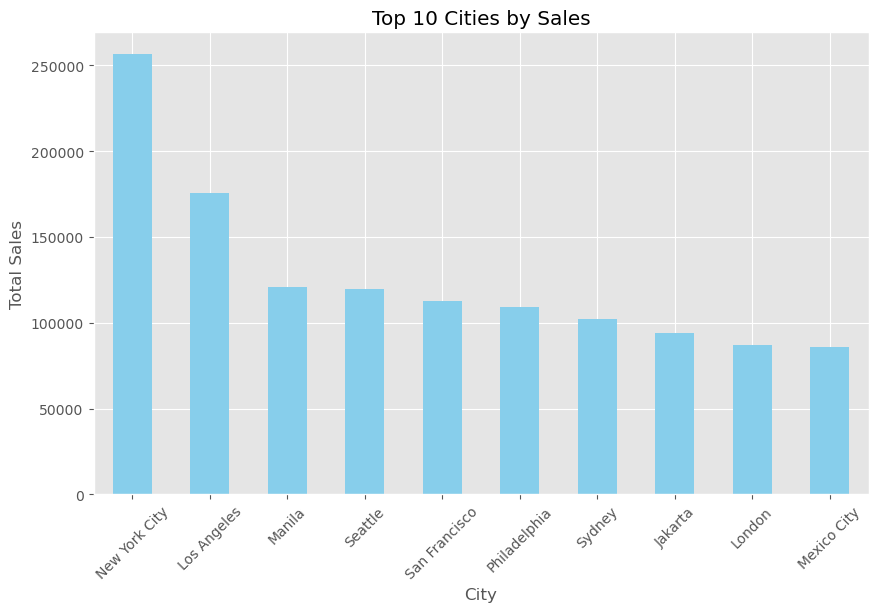

In [36]:
top_cities = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_cities.plot(kind="bar", color="skyblue")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

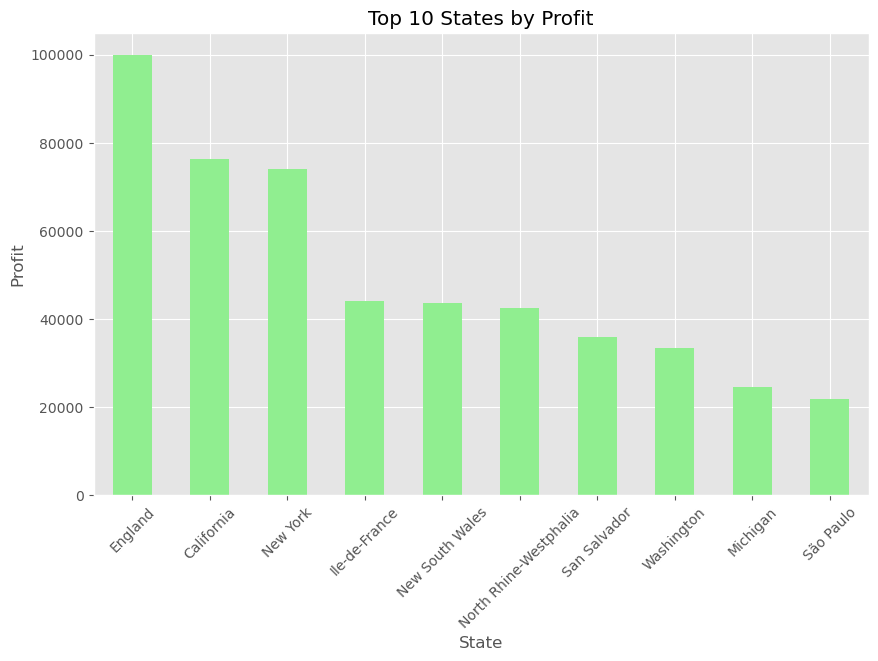

In [37]:
top_states = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_states.plot(kind="bar", color="lightgreen")

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.show()

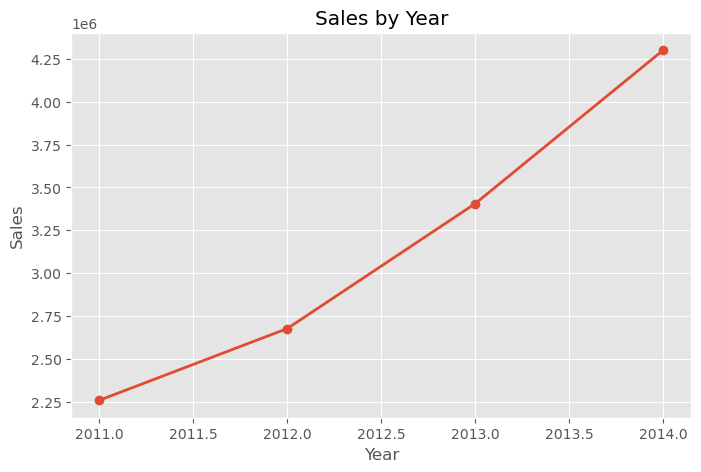

In [38]:
sales_year = (
    df.groupby("Year")["Sales"]
      .sum()
)

plt.figure(figsize=(8,5))

sales_year.plot(marker="o", linewidth=2)

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

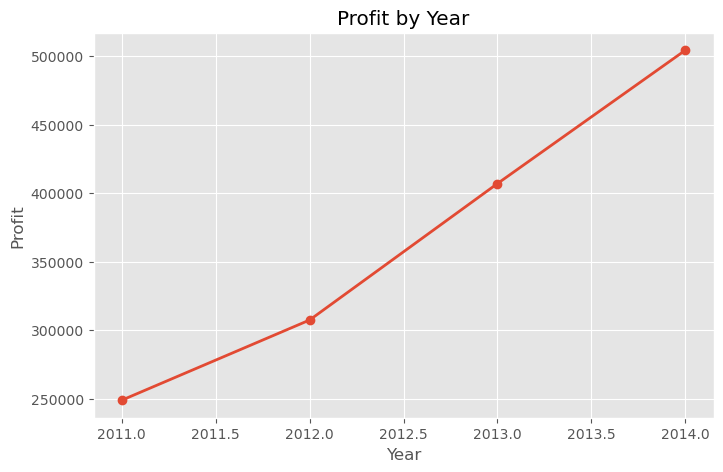

In [39]:
profit_year = (
    df.groupby("Year")["Profit"]
      .sum()
)

plt.figure(figsize=(8,5))

profit_year.plot(marker="o", linewidth=2)

plt.title("Profit by Year")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.grid(True)

plt.show()

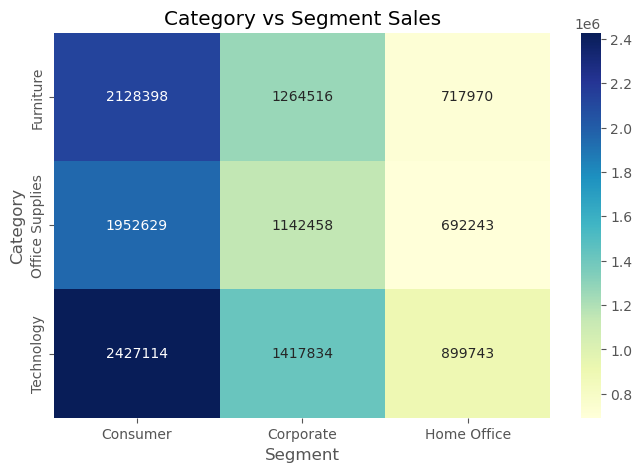

In [40]:
category_segment = pd.pivot_table(
    df,
    values="Sales",
    index="Category",
    columns="Segment",
    aggfunc="sum"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    category_segment,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category vs Segment Sales")

plt.show()

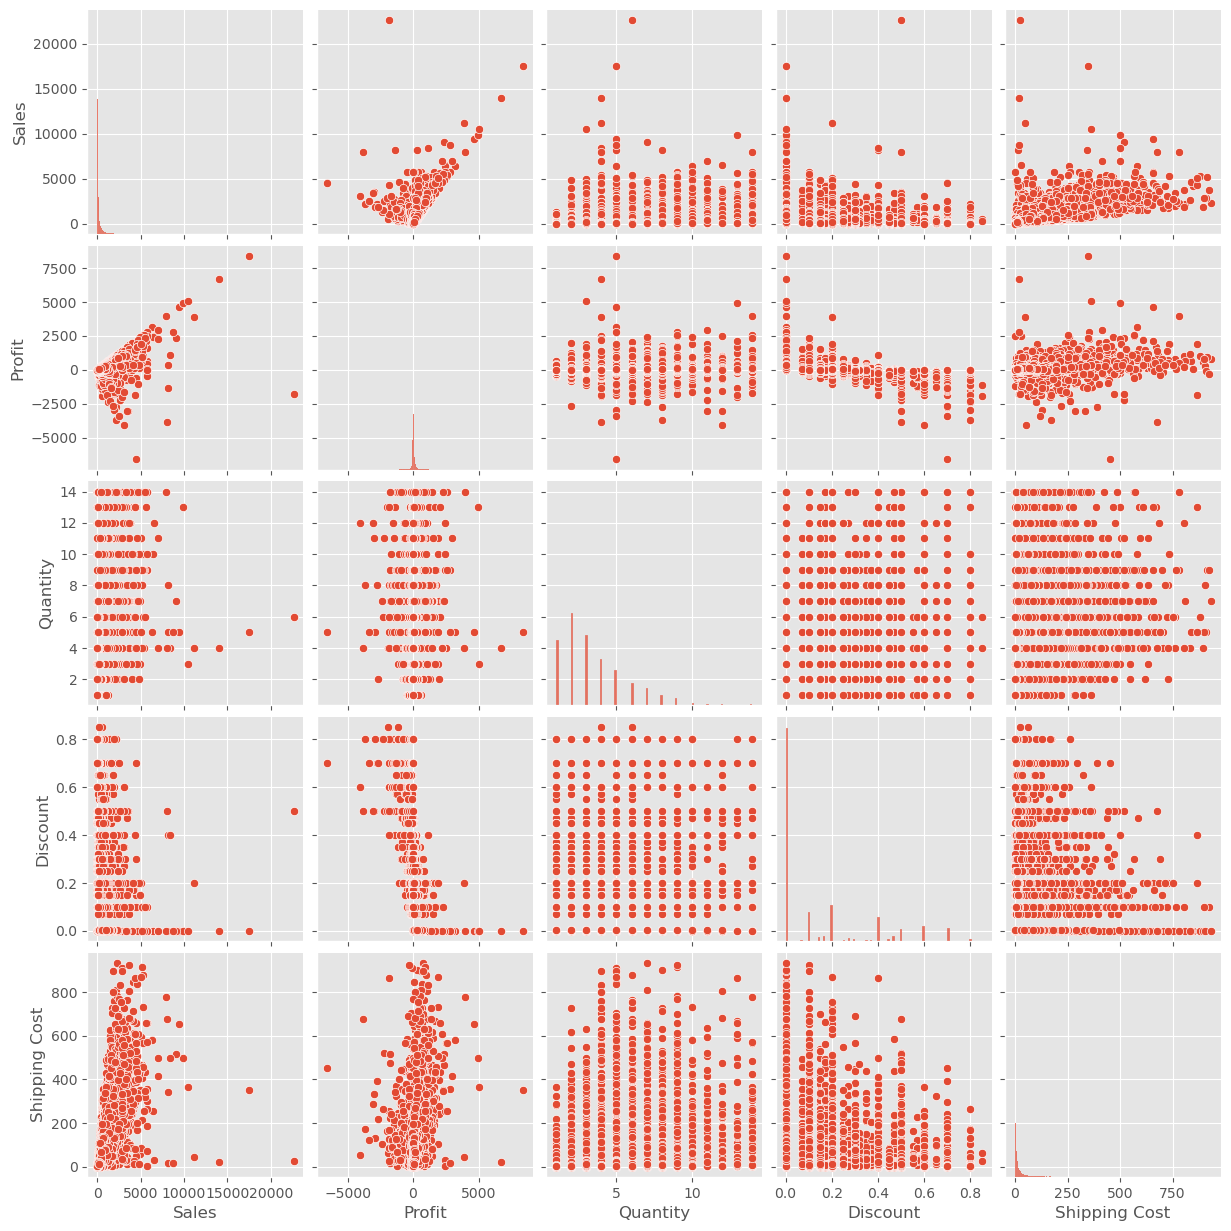

In [41]:
numeric_columns = [
    "Sales",
    "Profit",
    "Quantity",
    "Discount",
    "Shipping Cost"
]

sns.pairplot(df[numeric_columns])

plt.show()